# Telco Customer Churn - Feature Engineering

#### In this notebook, we create new features that may improve churn prediction.

##### New features created:
 - **TotalServices** : number of add-on services used by the customer
 - **TenureGroup** : customer lifecycle stage based on tenure months

In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Display all columns
pd.set_option('display.max_columns',None)

### 1: Load Processed Dataset

In [28]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")
df.head(3)

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1


### 2 : TotalServices feature

This feature represents the total number of additional services a customer has subscribed to.

#### 2.1. Define service columns

In [29]:
# List of service related features offered to customers
# These will be used to compute total service usage
service_cols = ['Online Security','Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies']

#### 2.2. Create count of total services

In [30]:
# Count number of services where customer has 'Yes'
# This converts multiple binary features into a single engagement metric
df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)

#### 2.3. Verify the feature

We verify the distribution of the TotalServices feature to ensure:
 - Values are within expected range
 - No unexpected anomalies exist

In [31]:
df['TotalServices'].describe()

count    7043.000000
mean        2.037910
std         1.847682
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: TotalServices, dtype: float64

In [32]:
df['TotalServices'].value_counts()

TotalServices
0    2219
3    1118
2    1033
1     966
4     852
5     571
6     284
Name: count, dtype: int64

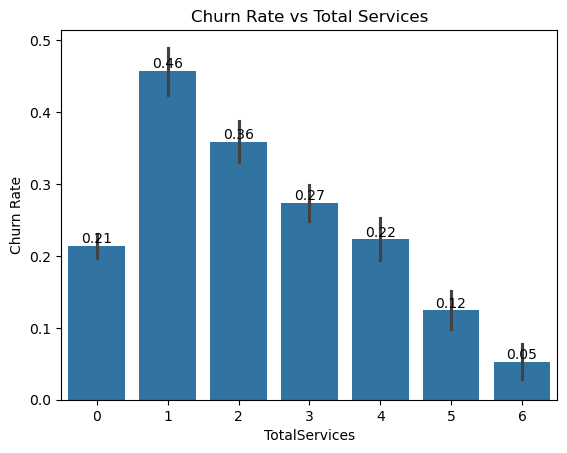

In [33]:
ax = sns.barplot(data=df, x='TotalServices', y='Churn Value')

for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")
plt.title('Churn Rate vs Total Services')
plt.ylabel('Churn Rate')
plt.show()

 - Customers with only one service show the highest churn rate(~46%) indicating low engagement and higher likelihood of leaving.
 - As the number of services increases, churn rate steadily decreases, reaching as low as ~5% for customers using 6 services.
 - Customers with zero services(minimal users) have lower churn than those with one service.
 - This feature helps to capture overall customer engagement in a single numerical variable and suggests that higher service adoption is strongly associated with improved customer retention.

### 3 : TenureGroup feature

This feature groups customers based on their tenure (in months) into lifecycle stages.

#### 3.1. Create tenure groups

In [34]:
# Define tenure bins 
# Using np.inf ensures all values are covered
bins = [0, 12, 24, 48, 72, np.inf]
labels = ['0-12', '12-24', '24-48', '48-72', '72+']

# Convert continuous tenure into categorical groups
df['TenureGroup'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels, right=False)

#### 3.2. verify the feature 

we analyze churn rate across tenure groups to validate whether this feature captures meaningful patterns.

In [35]:
df['TenureGroup'].value_counts()

TenureGroup
0-12     2069
48-72    1941
24-48    1624
12-24    1047
72+       362
Name: count, dtype: int64

In [36]:
df['TenureGroup'].describe()

count     7043
unique       5
top       0-12
freq      2069
Name: TenureGroup, dtype: object

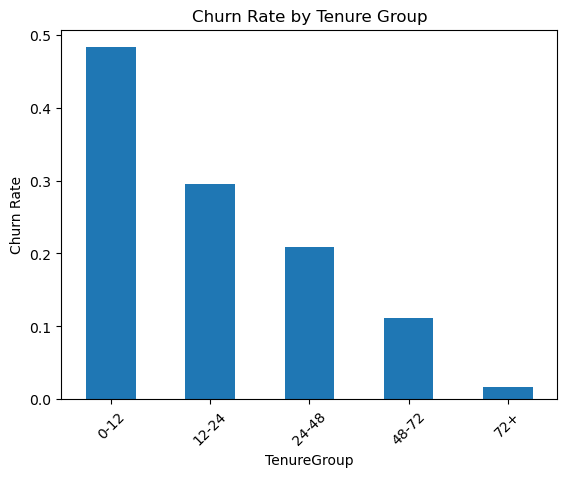

In [37]:
df.groupby('TenureGroup',observed=False)['Churn Value'].mean().plot(kind='bar')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()

 - Customers in the first year (0-12 months) show the highest churn rate(~48%)
 - while long-tenure customers (>48 months) show significantly lower churn risk(~11%)
 - This confirms that customer retention improves with time, and tenure is a strong predictor of churn behavior.

### 4 : Save the feature engineered dataset

New features have been created to capture customer behavior and lifecycle patterns. Based on analysis, selected features will be used in the modeling stage. The dataset is saved for further processing and modeling.

In [38]:
df.to_csv("../data/processed/telco_churn_features.csv", index=False)